In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [18]:
data = {
    "Age":[20,22,25,35,45,52,23,40,60,48],
    "Salary":[20000,25000,30000,80000,90000,120000,27000,70000,150000,100000],
    "Purchased":[0,0,0,1,1,1,0,1,1,1]
}

df = pd.DataFrame(data)

df

,Age,Salary,Purchased
0,20,20000,0
1,22,25000,0
2,25,30000,0
3,35,80000,1
4,45,90000,1
5,52,120000,1
6,23,27000,0
7,40,70000,1
8,60,150000,1
9,48,100000,1


In [19]:
x = df[["Age","Salary"]]
y = df["Purchased"]

In [20]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

In [14]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred= knn.predict(x_test)
print("Accuracy Without Scaling:",accuracy_score(y_test,y_pred))


Accuracy Without Scaling: 1.0


In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
scaled_df = pd.DataFrame(
    x_train_scaled,
    columns=["Age","Salary"]
)
print(scaled_df)

        Age    Salary
0 -1.323666 -1.289922
1  0.606680  0.339943
2 -0.841079 -0.963949
3  1.378819  1.317862
4  1.089267  0.991889
5  0.124094  0.665916
6 -1.034114 -1.061741


In [24]:
df =  sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
df.shape

(891, 15)

In [27]:
df.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [28]:
df2 = df[['survived','pclass','age','parch']]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [29]:
df2.isnull().sum()

survived      0
pclass        0
age         177
parch         0
dtype: int64

In [30]:
df2['pclass'].mean()

np.float64(2.308641975308642)

In [32]:
df2['age'].mean()

np.float64(29.69911764705882)

In [33]:
df2.describe()

,survived,pclass,age,parch
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,0.381594
std,0.486592,0.836071,14.526497,0.806057
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,38.000000,0.000000
max,1.000000,3.000000,80.000000,6.000000


In [34]:
df_fill = df2.fillna(df2.mean())

In [35]:
x = df2.drop('survived', axis = 1)
y = df2['survived']

In [37]:
print('shape of x', x.shape)
print('shape of y', y.shape)

shape of x (891, 3)
shape of y (891,)


In [43]:
# Train test

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=51)


In [44]:
print('Shape of X_train = ', x_train.shape)
print('Shape of y_train = ', y_train.shape)
print('Shape of X_test = ', x_test.shape)
print('Shape of y_test = ', y_test.shape)

Shape of X_train =  (712, 3)
Shape of y_train =  (712,)
Shape of X_test =  (179, 3)
Shape of y_test =  (179,)


In [45]:

sc = StandardScaler()
sc.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [46]:
sc.mean_

array([ 2.30617978, 29.51732394,  0.39185393])

In [47]:
sc.scale_


array([ 0.84405789, 14.54529745,  0.79647463])

In [49]:
x_train.describe()

,pclass,age,parch
count,712.000000,568.000000,712.000000
mean,2.306180,29.517324,0.391854
std,0.844651,14.558118,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,20.000000,0.000000
50%,3.000000,28.000000,0.000000
75%,3.000000,38.250000,0.000000
max,3.000000,71.000000,5.000000


In [50]:
sc.transform(x_train)

array([[ 0.8220055 , -0.37932012, -0.49198545],
       [ 0.8220055 ,  1.78632827, -0.49198545],
       [ 0.8220055 , -1.27307977, -0.49198545],
       ...,
       [ 0.8220055 ,  1.2706977 ,  3.27461284],
       [ 0.8220055 ,         nan,  0.76354731],
       [ 0.8220055 , -0.06994178, -0.49198545]], shape=(712, 3))

In [52]:
x_train_sc = sc.transform(x_train)
x_train_sc

array([[ 0.8220055 , -0.37932012, -0.49198545],
       [ 0.8220055 ,  1.78632827, -0.49198545],
       [ 0.8220055 , -1.27307977, -0.49198545],
       ...,
       [ 0.8220055 ,  1.2706977 ,  3.27461284],
       [ 0.8220055 ,         nan,  0.76354731],
       [ 0.8220055 , -0.06994178, -0.49198545]], shape=(712, 3))

In [53]:
 sc.transform(x_train)

array([[ 0.8220055 , -0.37932012, -0.49198545],
       [ 0.8220055 ,  1.78632827, -0.49198545],
       [ 0.8220055 , -1.27307977, -0.49198545],
       ...,
       [ 0.8220055 ,  1.2706977 ,  3.27461284],
       [ 0.8220055 ,         nan,  0.76354731],
       [ 0.8220055 , -0.06994178, -0.49198545]], shape=(712, 3))

In [55]:
x_train_sc = pd.DataFrame(x_train_sc,columns =['pclass','age','parch'])
x_train_sc

,pclass,age,parch
0,0.822005,-0.379320,-0.491985
1,0.822005,1.786328,-0.491985
2,0.822005,-1.273080,-0.491985
3,0.822005,-0.791825,-0.491985
4,0.822005,NaN,2.019080
...,...,...,...
707,0.822005,0.651941,-0.491985
708,0.822005,NaN,0.763547
709,0.822005,1.270698,3.274613
710,0.822005,NaN,0.763547


In [56]:
x_train_sc.describe()

,pclass,age,parch
count,7.120000e+02,5.680000e+02,7.120000e+02
mean,1.160121e-16,5.472930e-17,6.237208e-17
std,1.000703e+00,1.000881e+00,1.000703e+00
min,-1.547500e+00,-2.000463e+00,-4.919855e-01
25%,-6.589356e-01,-6.543231e-01,-4.919855e-01
50%,8.220055e-01,-1.043171e-01,-4.919855e-01
75%,8.220055e-01,6.003780e-01,-4.919855e-01
max,8.220055e-01,2.851965e+00,5.785678e+00


In [57]:
x_train_sc.describe().round(2)

,pclass,age,parch
count,712.00,568.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.55,-2.00,-0.49
25%,-0.66,-0.65,-0.49
50%,0.82,-0.10,-0.49
75%,0.82,0.60,-0.49
max,0.82,2.85,5.79


In [62]:
x_test_sc = sc.transform(x_test)
x_test_sc

array([[-1.54750023,  0.72069176, -0.49198545],
       [ 0.8220055 ,  0.17068582, -0.49198545],
       [ 0.8220055 ,  0.03318434, -0.49198545],
       [-1.54750023,         nan, -0.49198545],
       [-0.36274737,  0.30818731,  0.76354731],
       [ 0.8220055 ,  0.17068582, -0.49198545],
       [-1.54750023,  1.20194696, -0.49198545],
       [ 0.8220055 , -0.92932606, -0.49198545],
       [-0.36274737,  2.50821107, -0.49198545],
       [-1.54750023, -0.9980768 ,  0.76354731],
       [-0.36274737,  0.10193508, -0.49198545],
       [-0.36274737, -0.10431715, -0.49198545],
       [-1.54750023,  1.06444547, -0.49198545],
       [ 0.8220055 , -0.44807086, -0.49198545],
       [ 0.8220055 ,  0.7894425 ,  5.78567837],
       [-0.36274737, -0.31056938, -0.49198545],
       [-0.36274737,  0.44568879,  2.01908008],
       [ 0.8220055 ,         nan, -0.49198545],
       [ 0.8220055 ,         nan, -0.49198545],
       [-0.36274737, -0.72307383, -0.49198545],
       [ 0.8220055 ,         nan, -0.491

In [61]:
x_test_sc = pd.DataFrame(x_test_sc,columns =['pclass','age','parch'])
x_test_sc

,pclass,age,parch
0,0.822005,-0.379320,-0.491985
1,0.822005,1.786328,-0.491985
2,0.822005,-1.273080,-0.491985
3,0.822005,-0.791825,-0.491985
4,0.822005,NaN,2.019080
...,...,...,...
707,0.822005,0.651941,-0.491985
708,0.822005,NaN,0.763547
709,0.822005,1.270698,3.274613
710,0.822005,NaN,0.763547


In [60]:
x_test_sc.describe()

,pclass,age,parch
count,7.120000e+02,5.680000e+02,7.120000e+02
mean,1.160121e-16,5.472930e-17,6.237208e-17
std,1.000703e+00,1.000881e+00,1.000703e+00
min,-1.547500e+00,-2.000463e+00,-4.919855e-01
25%,-6.589356e-01,-6.543231e-01,-4.919855e-01
50%,8.220055e-01,-1.043171e-01,-4.919855e-01
75%,8.220055e-01,6.003780e-01,-4.919855e-01
max,8.220055e-01,2.851965e+00,5.785678e+00


In [64]:
mnc = MinMaxScaler()

In [65]:
mnc.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [66]:
x_test_mnc = mnc.transform(x_train)
x_test_mnc

array([[1.        , 0.33408898, 0.        ],
       [1.        , 0.78039105, 0.        ],
       [1.        , 0.14990082, 0.        ],
       ...,
       [1.        , 0.67412865, 0.6       ],
       [1.        ,        nan, 0.2       ],
       [1.        , 0.39784642, 0.        ]], shape=(712, 3))

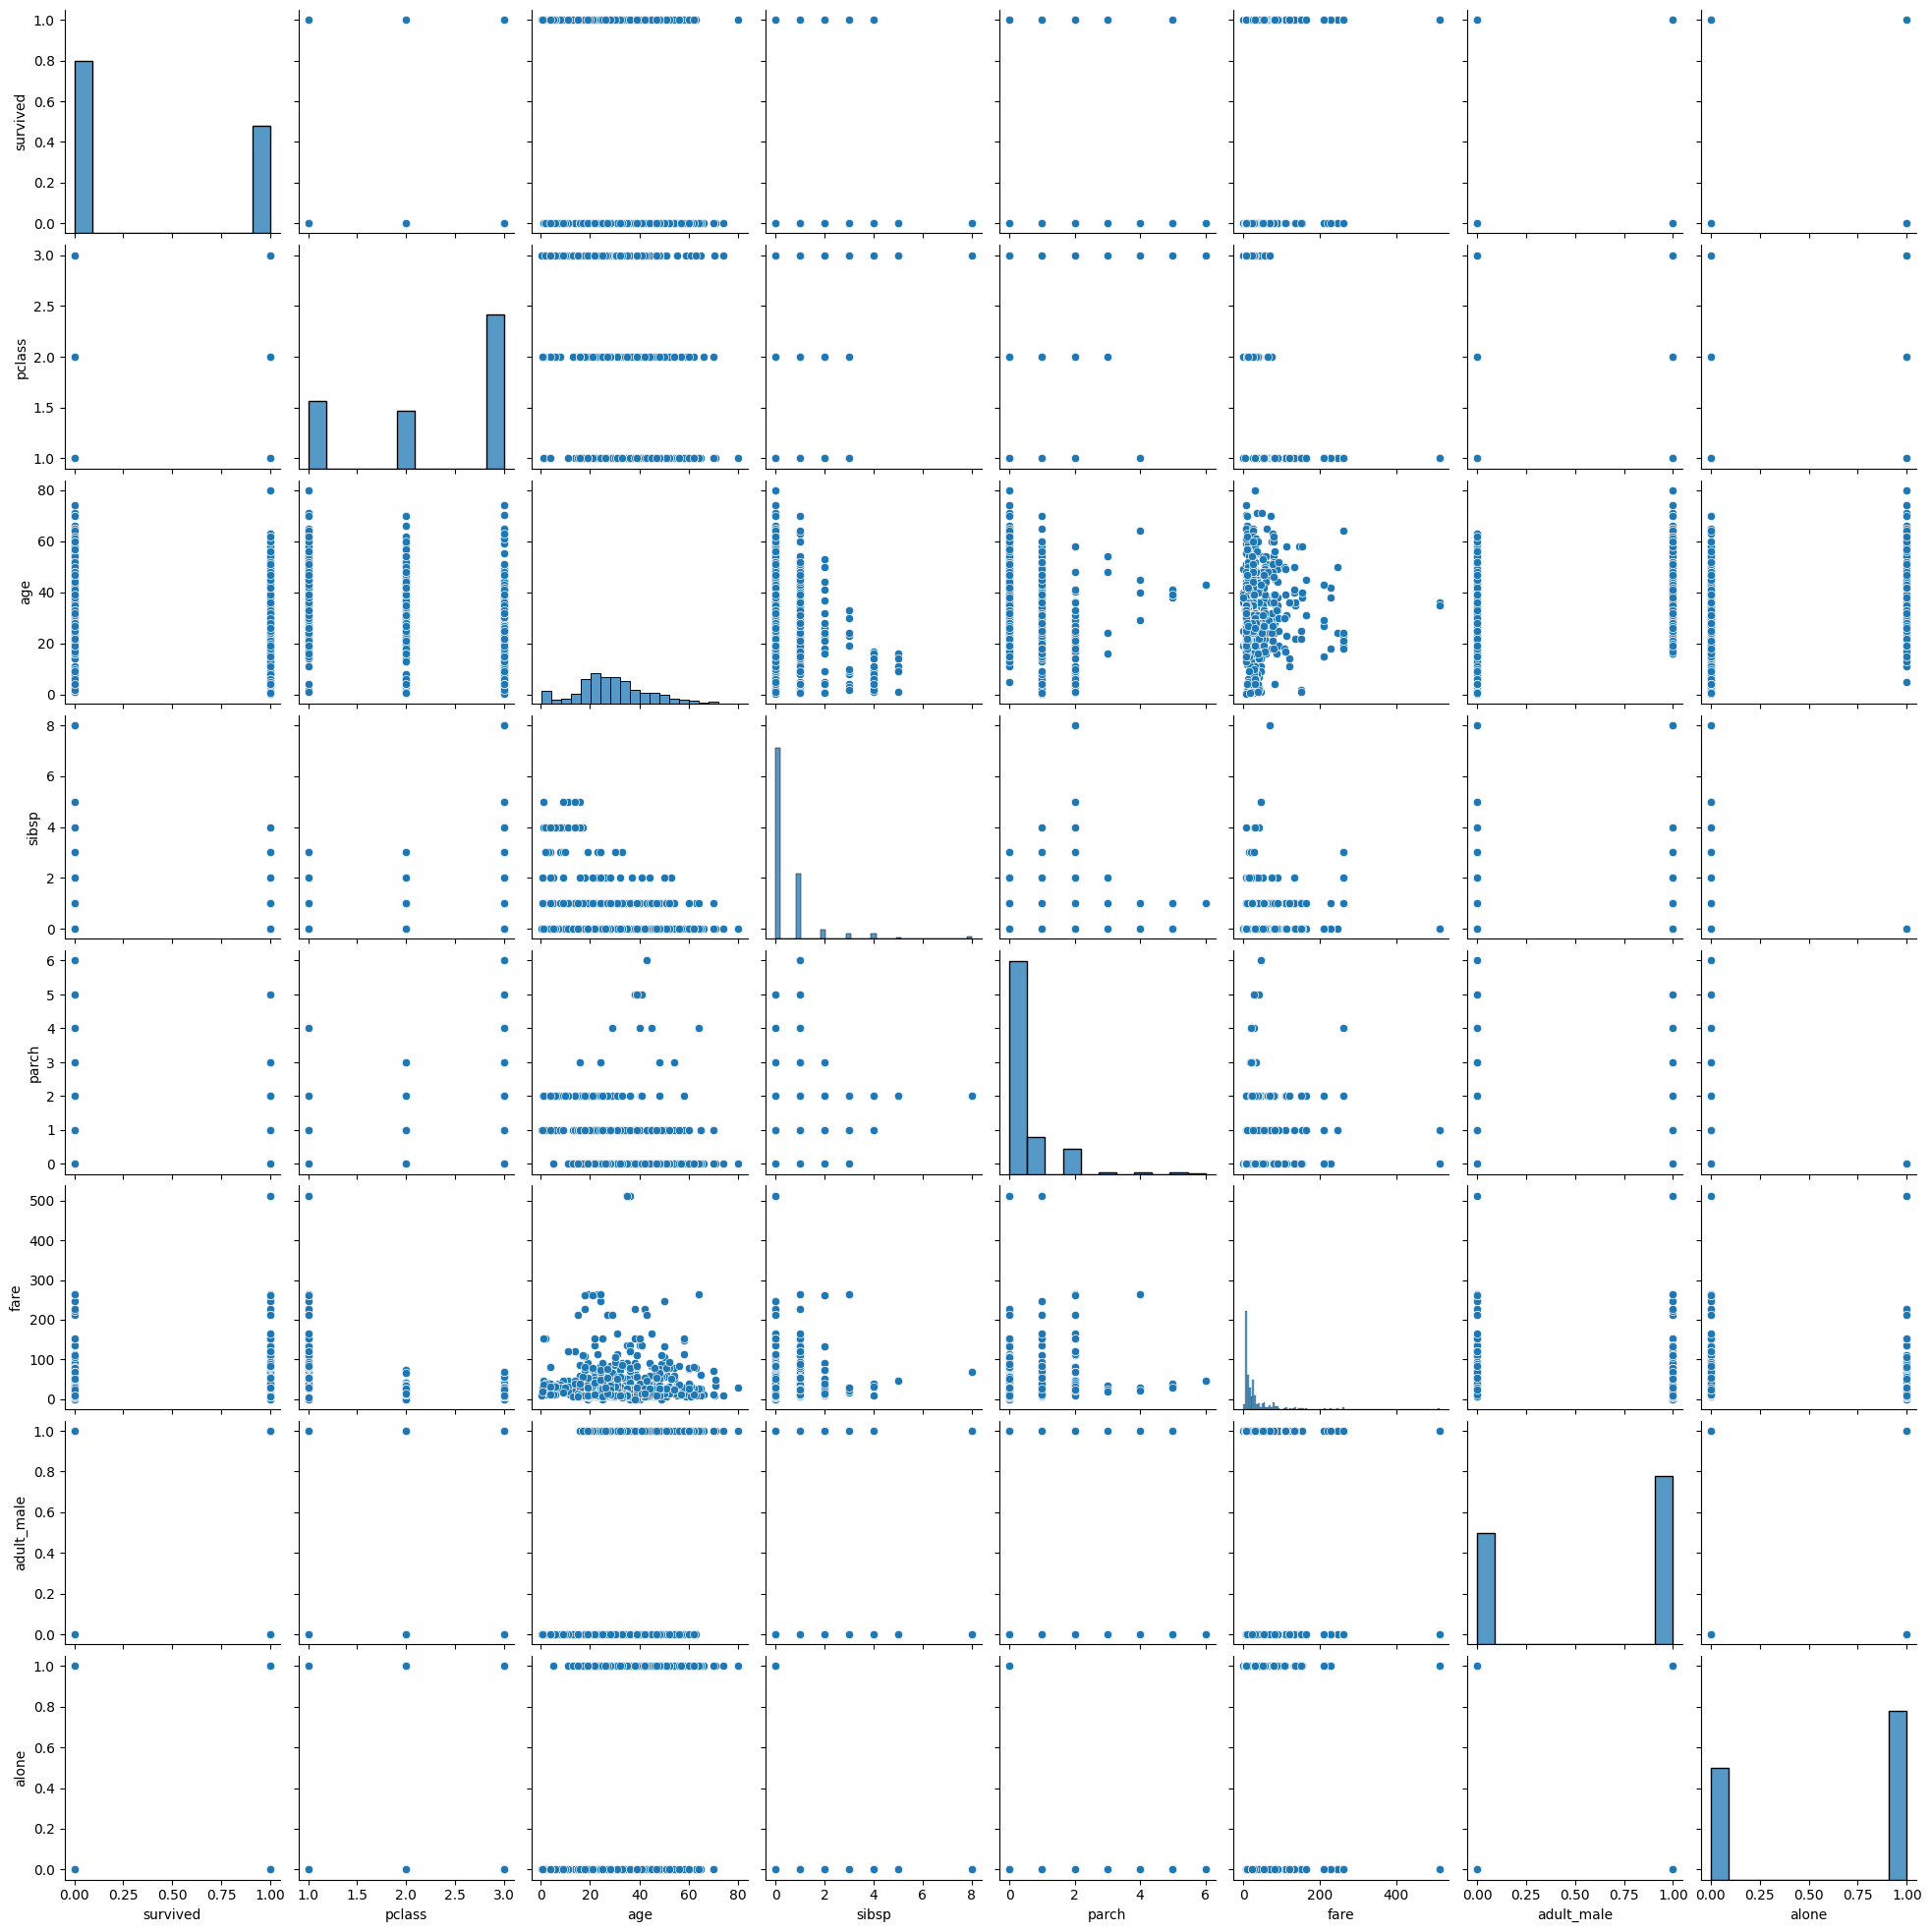

In [69]:
sns.pairplot(df)